# Unit 5 — 01: Monitoring a Production ML Model

**What you will do:** Build a complete monitoring pipeline for a deployed iris classifier — logging predictions, simulating traffic with a distribution shift, computing rolling statistics, and firing alerts.

**Why it matters:** A model that was 95% accurate in testing can silently degrade in production. Monitoring is the only way to catch it.

**How to run:** Python 3.10+. Run cells in order. Restart kernel if you re-run from the top.

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 3, lesson 01 "01. Logistic Regression and Classification Metrics" — you computed accuracy, precision and recall once, on a fixed test set; monitoring recomputes them over a rolling window of live traffic, where labels arrive late and the input distribution keeps moving.

---

## 📰 The outage that cost Robinhood $70 million

On **2 and 3 March 2020**, as US markets opened on record volume, Robinhood's trading platform went down — for most of a full trading day, then again the following day. Customers could not open the app, could not trade, and could not close positions. In **June 2021** FINRA settled with the firm: a **$57 million fine plus approximately $12.6 million in restitution**, the largest financial penalty FINRA had ever ordered. The finding named in the settlement is the sentence worth keeping: the firm *"failed to reasonably supervise the operation and maintenance of its technology."*

Not "wrote bad code". **Failed to supervise the operation.** Monitoring is not a nice-to-have that mature teams add later; in a regulated industry it is a documented obligation, and the absence of it is itself the finding.

**What goes wrong without this lesson.** A model that was 95% accurate in testing can degrade in production without a single error being raised, a single millisecond of extra latency, or a single line of code changing — because the world moved. And a service that is simply *down* looks identical, on a metrics dashboard that only tracks the model, to a service with no traffic. Monitoring is how you learn about both before a customer, or a regulator, tells you.

## Section 1 — What to Monitor

Four categories of production ML monitoring:

| Category | Examples | What it catches |
|---|---|---|
| **Infrastructure** | CPU %, memory usage, disk I/O | Server overload, OOM crashes |
| **Request metrics** | RPS, latency, HTTP error rate | Slow responses, service outages |
| **Prediction metrics** | Output class distribution, confidence scores | Silent failures, distribution shift |
| **Model quality** | Accuracy, F1 (when labels return) | Actual model degradation |

In this notebook we focus on **request metrics** and **prediction metrics** because they are available immediately — model quality labels often arrive days later.

## Section 2 — PredictionLogger

Every prediction is written to a JSON-lines log file. Each record contains: timestamp, input features, prediction, confidence, and latency.

In [1]:
# WHAT: build a PredictionLogger that appends every request to a JSON-lines file.
# WHY: monitoring is impossible without records — each line captures the five
# facts (input, output, confidence, latency, time) every later analysis needs.
import json
import time
import pathlib
from datetime import datetime, timedelta
from typing import List, Dict

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

LOG_PATH = pathlib.Path("/tmp/prediction_log.jsonl")
LOG_PATH.unlink(missing_ok=True)  # start fresh each run


# Two jobs only: append one structured record, and read them all back.
class PredictionLogger:
    def __init__(self, log_path: pathlib.Path):
        self.log_path = log_path

    def log(self, features: List[float], prediction: int,
            confidence: float, latency_ms: float, timestamp: datetime) -> None:
        record = {
            "timestamp": timestamp.isoformat(),
            "features": features,
            "prediction": prediction,
            "confidence": round(confidence, 4),
            "latency_ms": round(latency_ms, 2),
        }
        with open(self.log_path, "a") as f:
            f.write(json.dumps(record) + "\n")

    def load_logs(self) -> List[Dict]:
        records = []
        with open(self.log_path) as f:
            for line in f:
                records.append(json.loads(line))
        return records


logger = PredictionLogger(LOG_PATH)
print("PredictionLogger ready. Log file:", LOG_PATH)

PredictionLogger ready. Log file: /tmp/prediction_log.jsonl


## Section 3 — Train a Model, Then Simulate 500 Requests

- Requests 1-400: normal iris features (no shift), latency ~30ms
- Requests 401-500: features multiplied by 1.5 (a sensor calibration change), AND the out-of-distribution inputs hit a slower path, pushing latency to ~120ms

We spread requests across a 24-hour window using datetime math so we can later compute per-hour statistics. Watch for two signals after the shift starts: the prediction class distribution changes, and p95 latency crosses the 100ms SLO.

In [2]:
# WHAT: train a model, then simulate a 24-hour day of 500 requests — the last
# 100 with shifted inputs AND degraded latency.
# WHY: we plant a known incident at request 400 so we can check that every
# monitoring technique below actually finds it.
rng = np.random.default_rng(42)

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)
print(f"Model trained. Test accuracy: {model.score(X_test, y_test):.3f}")

N_REQUESTS = 500
SHIFT_START = 400
window_start = datetime(2024, 1, 15, 0, 0, 0)
window_end   = datetime(2024, 1, 15, 23, 59, 59)
total_seconds = (window_end - window_start).total_seconds()

# Each iteration = one production request: pick input, apply shift if past
# the incident point, predict, and log with a realistic timestamp.
for i in range(N_REQUESTS):
    # pick a random sample from the test set
    idx = rng.integers(0, len(X_test))
    features = X_test[idx].copy()

    if i >= SHIFT_START:
        features = features * 1.5  # inject distribution shift
        # The shift also degrades serving latency: out-of-distribution inputs
        # take a slower path, so p95 latency climbs above the 100ms SLO.
        latency_ms = float(rng.normal(120, 25)) + (50 if rng.random() < 0.03 else 0)
    else:
        # normal traffic: latency ~30ms with occasional spikes
        latency_ms = float(rng.normal(30, 8)) + (50 if rng.random() < 0.03 else 0)
    latency_ms = max(5.0, latency_ms)

    proba = model.predict_proba(features.reshape(1, -1))[0]
    prediction = int(np.argmax(proba))
    confidence = float(np.max(proba))

    # spread evenly across 24 hours
    offset_s = (i / N_REQUESTS) * total_seconds
    ts = window_start + timedelta(seconds=offset_s)

    logger.log(features.tolist(), prediction, confidence, latency_ms, ts)

print(f"Logged {N_REQUESTS} requests ({SHIFT_START} normal, {N_REQUESTS - SHIFT_START} shifted)")

Model trained. Test accuracy: 1.000


Logged 500 requests (400 normal, 100 shifted)


## Section 4 — Rolling Statistics: Requests Per Hour, Latency, Class Distribution

Load the logs and compute:
- **Requests per hour** — traffic volume
- **Mean and p95 latency** — response time health
- **Prediction class distribution over time** — proxy for input shift

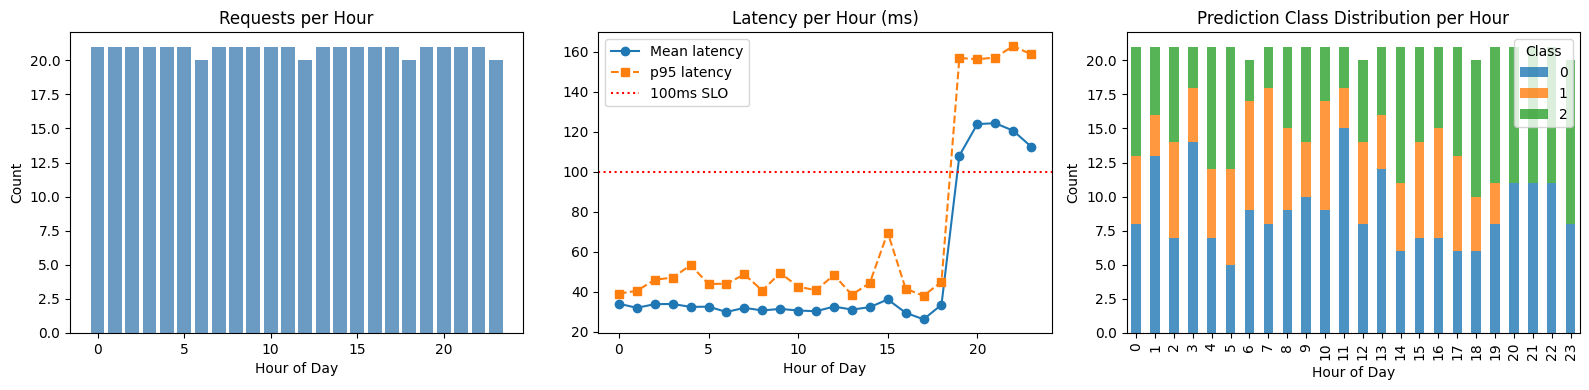

Notice how class distribution shifts after hour ~19 (the 400-request mark).


In [3]:
# WHAT: load the log into pandas and plot three per-hour panels: traffic,
# latency (mean + p95 vs SLO), and prediction class mix.
# WHY: these are the three panels of a real serving dashboard — and the hourly
# grouping shows the incident appearing near hour 19.
import pandas as pd

records = logger.load_logs()
df = pd.DataFrame(records)
df["timestamp"] = pd.to_datetime(df["timestamp"], format="ISO8601")
df["hour"] = df["timestamp"].dt.hour

# --- Requests per hour ---
rph = df.groupby("hour").size().rename("count")

# --- Latency stats per hour ---
lat_mean = df.groupby("hour")["latency_ms"].mean()
lat_p95  = df.groupby("hour")["latency_ms"].quantile(0.95)

# --- Prediction class distribution per hour ---
class_dist = df.groupby(["hour", "prediction"]).size().unstack(fill_value=0)

# Left: request volume. Middle: latency vs the 100ms SLO. Right: class mix.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(rph.index, rph.values, color="steelblue", alpha=0.8)
axes[0].set_title("Requests per Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Count")

axes[1].plot(lat_mean.index, lat_mean.values, label="Mean latency", marker="o")
axes[1].plot(lat_p95.index, lat_p95.values, label="p95 latency", marker="s", linestyle="--")
axes[1].axhline(100, color="red", linestyle=":", label="100ms SLO")
axes[1].set_title("Latency per Hour (ms)")
axes[1].set_xlabel("Hour of Day")
axes[1].legend()

class_dist.plot(ax=axes[2], kind="bar", stacked=True, alpha=0.8)
axes[2].set_title("Prediction Class Distribution per Hour")
axes[2].set_xlabel("Hour of Day")
axes[2].set_ylabel("Count")
axes[2].legend(title="Class")

plt.tight_layout()
plt.savefig("/tmp/monitoring_rolling_stats.png", dpi=72)
plt.show()
print("Notice how class distribution shifts after hour ~19 (the 400-request mark).")

## Section 5 — Confidence Score Tracking

When input data shifts away from the training distribution, the model's confidence typically drops. Plot rolling average confidence to catch this early — before ground-truth labels arrive.

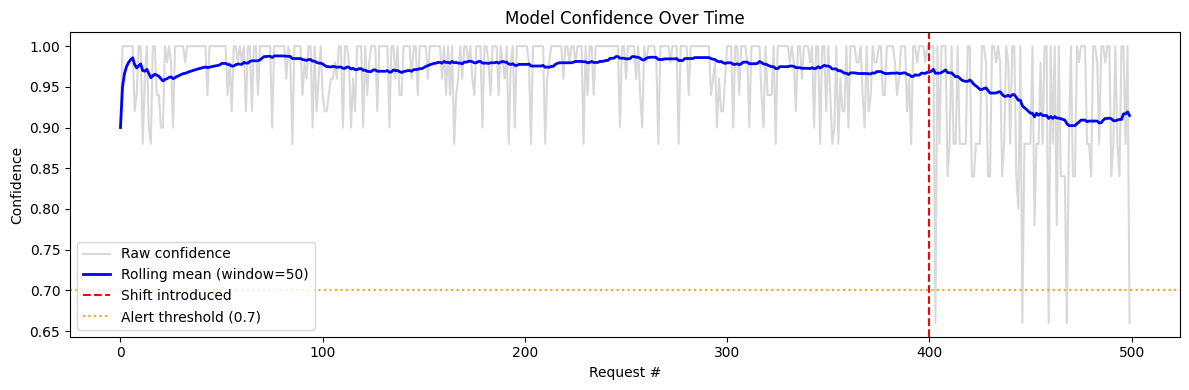

Confidence drops visibly after the shift — an early warning signal.


In [4]:
# WHAT: plot per-request confidence with a 50-request rolling mean.
# WHY: raw confidence is noisy; the rolling mean turns it into a trend line
# that visibly dips at the planted shift — the signal an alert would use.
WINDOW = 50  # rolling window size

df_sorted = df.sort_values("timestamp").reset_index(drop=True)
df_sorted["rolling_confidence"] = df_sorted["confidence"].rolling(WINDOW, min_periods=1).mean()

plt.figure(figsize=(12, 4))
plt.plot(df_sorted.index, df_sorted["confidence"], alpha=0.3, color="gray", label="Raw confidence")
plt.plot(df_sorted.index, df_sorted["rolling_confidence"], color="blue",
         linewidth=2, label=f"Rolling mean (window={WINDOW})")
plt.axvline(SHIFT_START, color="red", linestyle="--", label="Shift introduced")
plt.axhline(0.7, color="orange", linestyle=":", label="Alert threshold (0.7)")
plt.title("Model Confidence Over Time")
plt.xlabel("Request #")
plt.ylabel("Confidence")
plt.legend()
plt.tight_layout()
plt.savefig("/tmp/monitoring_confidence.png", dpi=72)
plt.show()
print("Confidence drops visibly after the shift — an early warning signal.")

## Section 6 — Simple Alerting Function

An alerting function evaluates a rolling window of recent logs and fires if thresholds are breached. Because our injected shift also degraded latency, the **last 100 (shifted) requests should trip the p95-latency alert**, while the first 400 (normal) requests stay clean — exactly the behaviour you want from monitoring.

In [5]:
# WHAT: turn the plots into code — check_alerts() compares recent windows
# against confidence and latency thresholds.
# WHY: dashboards need humans watching; alerts don't. The same function is run
# on the shifted window (should fire) and the normal window (should stay quiet).
from typing import List, Dict, Optional


def check_alerts(
    recent_logs: List[Dict],
    confidence_threshold: float = 0.7,
    p95_latency_threshold_ms: float = 100.0,
) -> List[str]:
    """Return a list of alert strings for any breached thresholds."""
    alerts = []

    latencies = [r["latency_ms"] for r in recent_logs]
    confidences = [r["confidence"] for r in recent_logs]

    mean_confidence = float(np.mean(confidences))
    p95_latency = float(np.percentile(latencies, 95))

    if mean_confidence < confidence_threshold:
        alerts.append(
            f"ALERT: Low confidence — mean={mean_confidence:.3f} < threshold={confidence_threshold}"
        )
    if p95_latency > p95_latency_threshold_ms:
        alerts.append(
            f"ALERT: High p95 latency — {p95_latency:.1f}ms > threshold={p95_latency_threshold_ms}ms"
        )

    return alerts


# Evaluate on the last 100 requests (the shifted ones)
all_logs = logger.load_logs()
recent_100 = all_logs[-100:]

print("=== Alerts for last 100 requests (shifted data) ===")
alerts = check_alerts(recent_100)
if alerts:
    for a in alerts:
        print(a)
else:
    print("No alerts. All metrics within thresholds.")

print()

# Evaluate on the first 400 requests (normal)
first_400 = all_logs[:400]
print("=== Alerts for first 400 requests (normal data) ===")
alerts_normal = check_alerts(first_400)
if alerts_normal:
    for a in alerts_normal:
        print(a)
else:
    print("No alerts. All metrics within thresholds.")

=== Alerts for last 100 requests (shifted data) ===
ALERT: High p95 latency — 163.3ms > threshold=100.0ms

=== Alerts for first 400 requests (normal data) ===
No alerts. All metrics within thresholds.


## 💬 Discuss

Two contrasts came out of the alerting run. The last 100 (shifted) requests fired **`High p95 latency — 163.3ms > threshold=100.0ms`**; the first 400 (normal) requests fired nothing. Meanwhile the confidence chart dropped visibly at the same point — but no confidence alert fired, because the threshold was not crossed.

1. In this simulation the shift changed *both* the input distribution and the latency, so the latency alarm caught it. In the real Instacart and Zillow cases, latency never moved. If you could keep only one alert for a model like this, would you keep latency or confidence? Defend the choice, then say what you lose.
2. The four monitoring categories in section 1 have very different cost profiles: infrastructure metrics are nearly free, model-quality metrics require labels that may arrive weeks later. Given a fixed budget, in what order would you build them for a fraud model? For a recommendation model? Explain why the order differs.
3. Robinhood was penalised for failing to supervise its technology, not for a bad algorithm. If a Saudi bank deployed your model, what evidence would you want to be able to hand a regulator six months later — and does the log format in section 2 produce it?

## Summary

Four categories of production ML monitoring and what each catches:

1. **Infrastructure** (CPU, memory) — catches server overload before it causes outages
2. **Request metrics** (RPS, latency, error rate) — catches slow responses and service failures immediately
3. **Prediction metrics** (confidence, class distribution) — catches input distribution shift *without needing ground-truth labels*
4. **Model quality** (accuracy, F1) — confirms actual degradation but requires labels, which arrive with a delay

The key insight: **confidence drop is a leading indicator**. It fires before ground-truth labels arrive to confirm accuracy degradation.

## Self-Check (answer before scrolling back up)

1. **Why does mean latency hide problems that p95 catches?**  
   Mean latency is pulled down by the majority of fast requests, so occasional slow spikes (which impact 5% of users) are invisible. p95 directly measures the worst 5%.

2. **How can you monitor model quality without ground-truth labels?**  
   Track *prediction metrics* — confidence scores and output class distribution. If confidence drops or the class distribution shifts significantly, the model is likely encountering out-of-distribution data even before any labels come back.

3. **What does a sudden drop in average confidence likely indicate?**  
   The input feature distribution has changed (data drift). The model is receiving inputs far from its training distribution, so it cannot assign high probability to any single class.

## ⚠️ Where this breaks

- **Thresholds set without a baseline are guesses.** `p95 > 100 ms` fired here because the simulation was built to breach it. On a real service you must first measure the healthy distribution for a week, then set the threshold — otherwise you get an alarm that fires nightly during backups and is muted within a month. **The most common failure of alerting is not missing an incident; it is being ignored.**
- **Confidence is a weak proxy and this course keeps proving it.** In Unit 1 notebook 06, doubling every feature moved mean confidence by only 0.09. A drop is evidence; a lack of a drop is not reassurance.
- **A rolling window has a memory, and it hides slow decay.** Every statistic here compares recent traffic to a fixed reference. Drift that accumulates over months never produces a sharp step, so a window-based alert never fires — the baseline effectively moves with the problem if you ever recompute it from recent data.
- **The assumption that must hold:** requests keep arriving. Every metric in this notebook is computed *from* predictions. A service with zero traffic produces zero alerts and looks perfectly healthy, which is exactly the Robinhood shape. A liveness check is a separate mechanism, and notebook 03 adds it deliberately.
- **All 500 requests here were simulated, and simulation is generous.** Latency drawn from noise has no tail; real tails come from garbage collection, cold caches and retries. Real traffic also has weekends, holidays and bot storms. Nothing in this notebook prepares a threshold for those.
- **The cheaper alternative.** If your model is retrained monthly and its predictions are reviewed by a human before they act, a weekly report on a handful of numbers beats a real-time alerting stack that nobody has tuned. Real-time monitoring earns its cost when the decision is automatic and the time-to-detect matters.

## 📚 References

1. Breck, E., Cai, S., Nielsen, E., Salib, M., & Sculley, D. (2017). *The ML Test Score: A Rubric for ML Production Readiness and Technical Debt Reduction*. IEEE Big Data. <https://research.google/pubs/the-ml-test-score-a-rubric-for-ml-production-readiness-and-technical-debt-reduction/>
2. Rabanser, S., Günnemann, S., & Lipton, Z. C. (2019). *Failing Loudly: An Empirical Study of Methods for Detecting Dataset Shift*. NeurIPS. <https://arxiv.org/abs/1810.11953>
3. Klaise, J., Van Looveren, A., Cox, C., Vacanti, G., & Coca, A. (2020). *Monitoring and Explainability of Models in Production*. ICML Workshop on Challenges in Deploying and Monitoring ML Systems. <https://arxiv.org/abs/2007.06299>
